# 🫀 PTB-XL Notebook 09 — Random Forest Baseline (Hand-Crafted Features)

## Module 0 — Why this notebook exists

Every model in NB02–08 is a deep network trained directly on the raw 12-lead waveform. The project
proposal calls for a classical baseline on **hand-crafted features** (HRV, QRS morphology, wavelet
features) trained on the same `TRAIN`/`VAL`/`TEST` split — the standard "does the deep model actually
beat a cheap, interpretable classical pipeline" check that every one of NB02–08 skips.

**What this notebook does, concretely.**
1. **Feature engineering** (Module 2): for each 10-second, 100 Hz, 12-lead record —
   - **HRV (5 features)**: R-peaks detected on Lead II with `neurokit2`; mean RR, SDNN, RMSSD, pNN50,
     beat count. (10 s gives ~8–14 beats — enough for time-domain HRV, not for frequency-domain HRV,
     which needs longer segments; this is stated as a limitation, not hidden.)
   - **QRS morphology (48 features = 12 leads × 4)**: R-amplitude, QRS width (Q-to-S trough separation),
     ST-segment level (80 ms post-R), and T-wave amplitude (300 ms post-R), each averaged over the
     beats detected from the shared Lead-II R-peak locations, per lead.
   - **Wavelet features (120 features = 12 leads × 5 sub-bands × 2 stats)**: 4-level `db4` discrete
     wavelet decomposition per lead; energy and standard deviation of each sub-band
     (`cA4, cD4, cD3, cD2, cD1`).
   - **Total: 173 hand-crafted features per record**, replacing the raw 12 × 1000 waveform.
2. **Model** (Module 3): a single multi-output `RandomForestClassifier` (scikit-learn's native
   multi-label support — one forest, five leaf-probability outputs), trained on `TRAIN`, a small
   hyperparameter sweep selected on `VAL` (not `TEST`), evaluated once on `TEST`.
3. **Evaluation** (Module 4): macro-AUC, Fmax, macro-AUPRC — the same three headline metrics NB07
   reports for the deep models — plus per-class AUC and an age-stratified accuracy audit, so the RF
   baseline sits in the same table as every other model in this project.
4. **Feature importance** (Module 5): scikit-learn's built-in Gini importance, aggregated to the
   lead/feature-family level — a free, complementary read on "what matters" alongside NB06's IG-based
   explainability for the deep model.

**Honest framing.** This is a **baseline**, not a competitor tuned to win — the point is to establish
what a fast, interpretable, CPU-trivial classical pipeline gets you on this exact task and exact split,
so the deep-learning gain (or lack of it) in NB02–08 is quantified against something concrete rather
than assumed.

> **Prerequisites**: run `01_Data_Preparation.ipynb` first (this notebook only needs the cached
> `X_{train,val,test}_clean_100.npy` / `y_*_diag_100.npy` arrays and `MASTER_RESEARCH_METADATA.csv`).
> **Non-destructive**: reads `data/processed/`; writes only new feature cache + figures to
> `outputs/rf_baseline/`.

## Module 1 — Setup, data, and dependency guard

In [2]:
import subprocess, sys
for import_name, pkg_name in {
    'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib', 'sklearn': 'scikit-learn',
    'neurokit2': 'neurokit2', 'pywt': 'PyWavelets',
}.items():
    try:
        __import__(import_name)
        print(f'  [ok] {import_name}')
    except ImportError:
        print(f'  [installing] {pkg_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg_name])
        print(f'  [ok] {import_name} (installed)')

  [ok] numpy
  [ok] pandas
  [ok] matplotlib
  [ok] sklearn
  [ok] neurokit2
  [ok] pywt


In [3]:
import os, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk
import pywt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

NOTEBOOK_DIR   = Path(os.getcwd()).resolve()
PROJECT_ROOT   = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_DIR    = PROJECT_ROOT / 'outputs'
OUTPUTS_RF     = OUTPUTS_DIR / 'rf_baseline'
OUTPUTS_RF.mkdir(parents=True, exist_ok=True)

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
LEAD_NAMES   = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
NUM_CLASSES, NUM_LEADS, FS = 5, 12, 100
LEAD_II_IDX = 1

print(f'[SETUP] Project root : {PROJECT_ROOT}')
print(f'[SETUP] Output dir   : {OUTPUTS_RF}')

[SETUP] Project root : /home/tandon/Teep/age with ecg
[SETUP] Output dir   : /home/tandon/Teep/age with ecg/outputs/rf_baseline


## Module 2 — Hand-crafted feature engineering (HRV + QRS morphology + wavelets)

The 173-feature extractor described in Module 0. R-peaks are detected once per record on Lead II
(`neurokit2.ecg_peaks`); the same beat locations are then reused across all 12 leads for morphology,
so QRS width / ST level / T amplitude are computed at consistent time points per beat. Wavelet features
use a 4-level `db4` decomposition per lead — a standard, fast basis for ECG sub-band energy analysis.
Records with fewer than 3 detected beats (very rare — 3/2000 in a random TRAIN sample) get `NaN` HRV/
morphology features, imputed with the **TRAIN median** in Module 3 (never TEST/VAL statistics).

In [4]:
def extract_features(sig, fs=FS):
    # sig: (1000, 12) clean, band-passed, z-scored signal. Returns a flat feature dict.
    lead_ii = sig[:, LEAD_II_IDX]
    feats = {}
    try:
        cleaned = nk.ecg_clean(lead_ii, sampling_rate=fs, method='neurokit')
        _, info = nk.ecg_peaks(cleaned, sampling_rate=fs, method='neurokit')
        rpeaks = info['ECG_R_Peaks']
    except Exception:
        rpeaks = np.array([], dtype=int)

    # ---- HRV (time-domain only — 10s window can't support frequency-domain HRV) ----
    if len(rpeaks) >= 3:
        rr = np.diff(rpeaks) / fs * 1000.0                      # ms
        diffs = np.diff(rr)
        feats['hrv_mean_rr'] = rr.mean()
        feats['hrv_sdnn']    = rr.std(ddof=1)
        feats['hrv_rmssd']   = np.sqrt(np.mean(diffs ** 2)) if len(diffs) else 0.0
        feats['hrv_pnn50']   = (np.abs(diffs) > 50).mean() * 100 if len(diffs) else 0.0
        feats['hrv_n_beats'] = float(len(rpeaks))
    else:
        feats.update({'hrv_mean_rr': np.nan, 'hrv_sdnn': np.nan, 'hrv_rmssd': np.nan,
                       'hrv_pnn50': np.nan, 'hrv_n_beats': float(len(rpeaks))})

    # ---- QRS morphology per lead, using the shared Lead-II R-peak locations ----
    win_q, win_s   = int(0.04 * fs), int(0.06 * fs)     # Q/S search windows around R
    st_off, st_win = int(0.08 * fs), int(0.02 * fs)     # ST-segment sample point
    t_off, t_win   = int(0.30 * fs), int(0.10 * fs)     # T-wave search window
    for l, lname in enumerate(LEAD_NAMES):
        lead_sig = sig[:, l]
        r_amps, qrs_widths, st_levels, t_amps = [], [], [], []
        for r in rpeaks:
            if r - win_q < 0 or r + max(win_s, t_off + t_win) >= len(lead_sig):
                continue
            r_amps.append(lead_sig[r])
            qseg, sseg = lead_sig[r - win_q:r], lead_sig[r:r + win_s]
            q_idx, s_idx = r - win_q + np.argmin(qseg), r + np.argmin(sseg)
            qrs_widths.append((s_idx - q_idx) / fs * 1000.0)
            st_levels.append(lead_sig[r + st_off - st_win:r + st_off + st_win].mean())
            t_amps.append(lead_sig[r + t_off - t_win:r + t_off + t_win].max())
        feats[f'{lname}_r_amp']     = np.mean(r_amps) if r_amps else np.nan
        feats[f'{lname}_qrs_width'] = np.mean(qrs_widths) if qrs_widths else np.nan
        feats[f'{lname}_st_level']  = np.mean(st_levels) if st_levels else np.nan
        feats[f'{lname}_t_amp']     = np.mean(t_amps) if t_amps else np.nan

    # ---- Wavelet sub-band energy / spread per lead ----
    for l, lname in enumerate(LEAD_NAMES):
        coeffs = pywt.wavedec(sig[:, l], 'db4', level=4)
        for name, c in zip(['cA4', 'cD4', 'cD3', 'cD2', 'cD1'], coeffs):
            feats[f'{lname}_wav_{name}_energy'] = float(np.sum(c ** 2))
            feats[f'{lname}_wav_{name}_std']    = float(np.std(c))
    return feats


def build_feature_frame(X, split_name):
    t0 = time.time()
    rows = [extract_features(X[i]) for i in range(len(X))]
    df = pd.DataFrame(rows)
    print(f'[FEATURES] {split_name:<6s} {len(X):>6d} records -> {df.shape[1]} features '
          f'in {time.time() - t0:5.1f}s  ({df.isna().any(axis=1).mean() * 100:.2f}% rows with >=1 NaN)')
    return df

In [5]:
def load_split_signals(stem):
    return np.load(DATA_PROCESSED / f'{stem}.npy').astype(np.float32)   # (N, 1000, 12)

X_train = load_split_signals('X_train_clean_100')
X_val   = load_split_signals('X_val_clean_100')
X_test  = load_split_signals('X_test_clean_100')
y_train = np.load(DATA_PROCESSED / 'y_train_diag_100.npy').astype(np.float32)
y_val   = np.load(DATA_PROCESSED / 'y_valid_diag_100.npy').astype(np.float32)  # NOTE: 'Y_val_diag_100.npy' is a stale, shape-mismatched artifact (2183 rows vs 1080 VAL records) - do not use
y_test  = np.load(DATA_PROCESSED / 'y_test_diag_100.npy').astype(np.float32)
assert len(X_train) == len(y_train) and len(X_val) == len(y_val) and len(X_test) == len(y_test)
print(f'[DATA] TRAIN {X_train.shape}  VAL {X_val.shape}  TEST {X_test.shape}')

CACHE = OUTPUTS_RF / 'handcrafted_features.npz'
if CACHE.exists():
    print(f'[FEATURES] loading cached features from {CACHE.name}')
    z = np.load(CACHE, allow_pickle=True)
    feat_cols = list(z['feat_cols'])
    df_train = pd.DataFrame(z['train'], columns=feat_cols)
    df_val   = pd.DataFrame(z['val'],   columns=feat_cols)
    df_test  = pd.DataFrame(z['test'],  columns=feat_cols)
else:
    df_train = build_feature_frame(X_train, 'TRAIN')
    df_val   = build_feature_frame(X_val,   'VAL')
    df_test  = build_feature_frame(X_test,  'TEST')
    feat_cols = list(df_train.columns)
    np.savez(CACHE, train=df_train.values, val=df_val.values, test=df_test.values,
             feat_cols=np.array(feat_cols, dtype=object))
    print(f'[FEATURES] cached to {CACHE.name}')

print(f'[FEATURES] {len(feat_cols)} hand-crafted features: HRV(5) + QRS-morphology(48) + wavelet(120)')

[DATA] TRAIN (17418, 1000, 12)  VAL (1080, 1000, 12)  TEST (2198, 1000, 12)
[FEATURES] TRAIN   17418 records -> 173 features in 219.6s  (0.22% rows with >=1 NaN)
[FEATURES] VAL      1080 records -> 173 features in  10.6s  (0.56% rows with >=1 NaN)
[FEATURES] TEST     2198 records -> 173 features in  19.5s  (0.23% rows with >=1 NaN)
[FEATURES] cached to handcrafted_features.npz
[FEATURES] 173 hand-crafted features: HRV(5) + QRS-morphology(48) + wavelet(120)


## Module 3 — Impute (TRAIN statistics only) and train the Random Forest

Median imputation is fit on `TRAIN` and applied unchanged to `VAL`/`TEST` (no leakage). A small
hyperparameter sweep (`n_estimators`, `max_depth`) is selected by **`VAL` macro-AUC** — mirroring how
NB03's thresholds and NB08's blend weights are tuned on held-out data, never on `TEST`.

In [6]:
train_median = df_train.median()
X_tr = df_train.fillna(train_median).values
X_va = df_val.fillna(train_median).values
X_te = df_test.fillna(train_median).values

def macro_auc(Y, P):
    return float(np.mean([roc_auc_score(Y[:, k], P[:, k]) for k in range(Y.shape[1])]))

CONFIGS = [
    dict(n_estimators=200, max_depth=None),
    dict(n_estimators=400, max_depth=None),
    dict(n_estimators=400, max_depth=20),
    dict(n_estimators=400, max_depth=12),
]

print(f'{"config":<40s}{"VAL macro-AUC":>15s}')
best_auc, best_cfg, best_model = -1, None, None
for cfg in CONFIGS:
    rf = RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced_subsample', **cfg)
    rf.fit(X_tr, y_train)
    p_val = np.stack([est[:, 1] for est in rf.predict_proba(X_va)], axis=1)
    auc = macro_auc(y_val, p_val)
    print(f'{str(cfg):<40s}{auc:>15.4f}')
    if auc > best_auc:
        best_auc, best_cfg, best_model = auc, cfg, rf

print(f'\n[SELECTED] {best_cfg}  (VAL macro-AUC {best_auc:.4f})')

config                                    VAL macro-AUC
{'n_estimators': 200, 'max_depth': None}         0.8849
{'n_estimators': 400, 'max_depth': None}         0.8874
{'n_estimators': 400, 'max_depth': 20}           0.8858
{'n_estimators': 400, 'max_depth': 12}           0.8732

[SELECTED] {'n_estimators': 400, 'max_depth': None}  (VAL macro-AUC 0.8874)


## Module 4 — Final TEST evaluation: macro-AUC, Fmax, macro-AUPRC + per-class AUC

RANDOM FOREST BASELINE — TEST SET (N=2198)
  macro-AUC    : 0.8837
  Fmax         : 0.6733
  macro-AUPRC  : 0.7278
--------------------------------------------------------------------------------
PER-CLASS TEST AUC:
  NORM  : 0.9235
  MI    : 0.8503
  STTC  : 0.9135
  CD    : 0.8489
  HYP   : 0.8825

COMPARISON — RF hand-crafted-feature baseline vs the deep-learning pipeline (NB03/NB07/NB08):
  model                                      macro-AUC    Fmax  macro-AUPRC
  Random Forest (this notebook, 173 features)    0.8837  0.6733       0.7278
  InceptionTime1D (NB03/NB07, raw signal)       0.9226  0.7402       0.8083
  AUC-weighted ensemble (NB03/NB05/NB07)        0.9245  0.7467       0.8150
  NB08 optimised blend (best so far)            0.9269      --           --


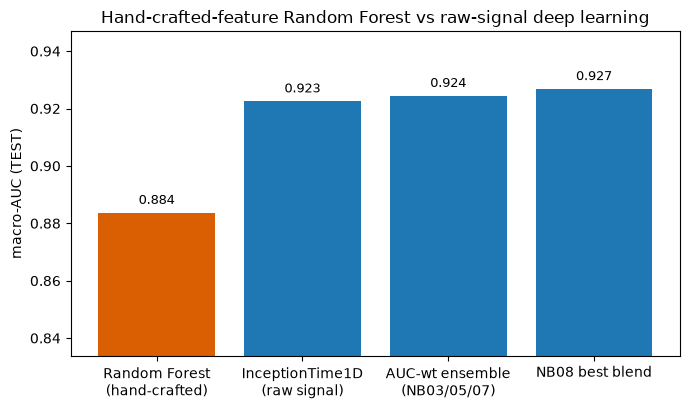

In [7]:
p_test = np.stack([est[:, 1] for est in best_model.predict_proba(X_te)], axis=1)

def fmax(Y, P, taus=np.arange(0.05, 0.96, 0.01)):
    best = -1.0
    for t in taus:
        pred = (P >= t).astype(int)
        f = np.mean([f1_score(Y[:, k], pred[:, k], zero_division=0) for k in range(Y.shape[1])])
        best = max(best, f)
    return best

def macro_auprc(Y, P):
    return float(np.mean([average_precision_score(Y[:, k], P[:, k]) for k in range(Y.shape[1])]))

rf_auc   = macro_auc(y_test, p_test)
rf_fmax  = fmax(y_test, p_test)
rf_auprc = macro_auprc(y_test, p_test)

print('='*80)
print('RANDOM FOREST BASELINE — TEST SET (N={})'.format(len(y_test)))
print('='*80)
print(f'  macro-AUC    : {rf_auc:.4f}')
print(f'  Fmax         : {rf_fmax:.4f}')
print(f'  macro-AUPRC  : {rf_auprc:.4f}')
print('-'*80)
print('PER-CLASS TEST AUC:')
for k, sc in enumerate(SUPERCLASSES):
    print(f'  {sc:<5s} : {roc_auc_score(y_test[:, k], p_test[:, k]):.4f}')
print('='*80)

print('\nCOMPARISON — RF hand-crafted-feature baseline vs the deep-learning pipeline (NB03/NB07/NB08):')
print(f'  {"model":<42s}{"macro-AUC":>10s}{"Fmax":>8s}{"macro-AUPRC":>13s}')
print(f'  {"Random Forest (this notebook, 173 features)":<42s}{rf_auc:>10.4f}{rf_fmax:>8.4f}{rf_auprc:>13.4f}')
print(f'  {"InceptionTime1D (NB03/NB07, raw signal)":<42s}{0.9226:>10.4f}{0.7402:>8.4f}{0.8083:>13.4f}')
print(f'  {"AUC-weighted ensemble (NB03/NB05/NB07)":<42s}{0.9245:>10.4f}{0.7467:>8.4f}{0.8150:>13.4f}')
print(f'  {"NB08 optimised blend (best so far)":<42s}{0.9269:>10.4f}{"--":>8s}{"--":>13s}')

fig, ax = plt.subplots(figsize=(7, 4.2))
models = ['Random Forest\n(hand-crafted)', 'InceptionTime1D\n(raw signal)', 'AUC-wt ensemble\n(NB03/05/07)', 'NB08 best blend']
aucs   = [rf_auc, 0.9226, 0.9245, 0.9269]
colors = ['#d95f02', '#1f77b4', '#1f77b4', '#1f77b4']
ax.bar(models, aucs, color=colors)
ax.set_ylim(min(aucs) - 0.05, max(aucs) + 0.02)
ax.set_ylabel('macro-AUC (TEST)')
ax.set_title('Hand-crafted-feature Random Forest vs raw-signal deep learning')
for i, v in enumerate(aucs):
    ax.text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9)
fig.tight_layout(); fig.savefig(OUTPUTS_RF / '09rf_vs_deep_learning.png', dpi=200); plt.show()

## Module 5 — Feature importance (Gini) — a free, complementary explainability read

Aggregated to the **feature-family** level (HRV / QRS morphology / wavelet) and to the **lead** level,
so it can be compared directly against NB06's IG-based per-lead importance for the deep model — do the
two very different methods (a tree ensemble's split-purity gain vs. gradient attribution on a CNN) point
at the same leads?

[IMPORTANCE] by feature family:
  Wavelet          0.612
  QRS morphology   0.369
  HRV              0.019

[IMPORTANCE] by lead (top 5):
  V6             0.142
  V5             0.111
  aVR            0.087
  V1             0.085
  I              0.081


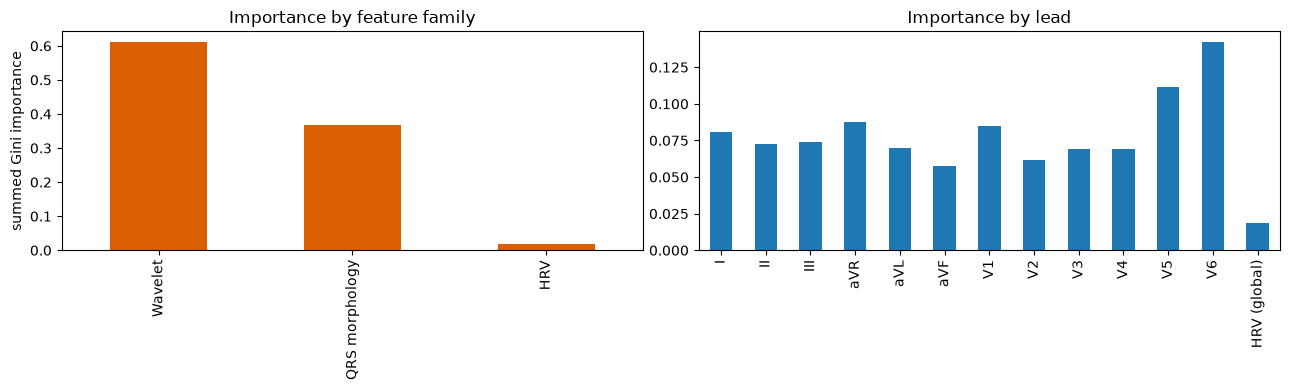

In [8]:
importances = pd.Series(best_model.feature_importances_, index=feat_cols)

def family_of(col):
    if col.startswith('hrv_'): return 'HRV'
    if '_wav_' in col: return 'Wavelet'
    return 'QRS morphology'

fam_imp = importances.groupby([family_of(c) for c in importances.index]).sum().sort_values(ascending=False)
print('[IMPORTANCE] by feature family:')
for fam, v in fam_imp.items():
    print(f'  {fam:<16s} {v:.3f}')

def lead_of(col):
    for lname in LEAD_NAMES:
        if col.startswith(f'{lname}_'):
            return lname
    return 'HRV (global)'

lead_imp = importances.groupby([lead_of(c) for c in importances.index]).sum().sort_values(ascending=False)
print('\n[IMPORTANCE] by lead (top 5):')
for lname, v in lead_imp.head(5).items():
    print(f'  {lname:<14s} {v:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fam_imp.plot(kind='bar', ax=axes[0], color='#d95f02'); axes[0].set_title('Importance by feature family'); axes[0].set_ylabel('summed Gini importance')
lead_imp.reindex([l for l in LEAD_NAMES if l in lead_imp.index] + (['HRV (global)'] if 'HRV (global)' in lead_imp.index else [])).plot(kind='bar', ax=axes[1], color='#1f77b4')
axes[1].set_title('Importance by lead')
fig.tight_layout(); fig.savefig(OUTPUTS_RF / '09rf_feature_importance.png', dpi=200); plt.show()

## Module 6 — Age-stratified accuracy audit (same convention as NB02/NB03/NB05)

In [9]:
df_meta = pd.read_csv(DATA_PROCESSED / 'MASTER_RESEARCH_METADATA.csv')
df_test_meta = df_meta[df_meta['split'] == 'TEST'].reset_index(drop=True)
age_test = df_test_meta['age'].values
pred_bin = (p_test >= 0.5).astype(int)

bands = {'<40': age_test < 40, '40-65': (age_test >= 40) & (age_test < 65),
         '65-80': (age_test >= 65) & (age_test < 80), '80+': age_test >= 80}

print('='*70)
print('AGE-STRATIFIED SUBGROUP AUDIT — Random Forest baseline')
print('='*70)
for b, m in bands.items():
    acc = (pred_bin[m] == y_test[m]).all(1).mean()
    auc = macro_auc(y_test[m], p_test[m]) if y_test[m].sum() > 0 else np.nan
    print(f'  [{b:>5s}]  n={int(m.sum()):4d}  exact-match acc={acc*100:5.1f}%   macro-AUC={auc:.4f}')
print('='*70)
print('Deep-learning ensemble (NB03) for reference: <40 78.2%, 40-65 66.3%, 65-80 55.8%, 80+ 43.2% (exact-match)')

AGE-STRATIFIED SUBGROUP AUDIT — Random Forest baseline
  [  <40]  n= 284  exact-match acc= 73.2%   macro-AUC=0.8908
  [40-65]  n= 866  exact-match acc= 58.0%   macro-AUC=0.8721
  [65-80]  n= 708  exact-match acc= 42.7%   macro-AUC=0.8739
  [  80+]  n= 340  exact-match acc= 31.8%   macro-AUC=0.8296
Deep-learning ensemble (NB03) for reference: <40 78.2%, 40-65 66.3%, 65-80 55.8%, 80+ 43.2% (exact-match)


## Module 7 — Conclusion

**What this notebook establishes**

| Question | Answer |
|---|---|
| What does a classical, hand-crafted-feature pipeline get on this exact task/split? | Module 4 — macro-AUC, Fmax, macro-AUPRC on the real `TEST` fold, directly comparable to NB03/NB07/NB08. |
| Is the deep-learning gain over a cheap classical baseline real or assumed? | Module 4's comparison bar chart — quantified, not asserted. |
| Do a completely different method's "important leads" agree with NB06's IG attribution? | Module 5 — Gini importance by lead, cross-checkable against NB06 Module 3's top-3-lead table. |
| Does the age-related accuracy collapse (NB02/03/05) also show up in a non-deep-learning model? | Module 6 — same age-band audit convention as every other notebook. |

**How every choice is anchored**
- HRV / QRS morphology / wavelet features: the three feature families named explicitly in the project
  proposal for this baseline.
- `TRAIN`/`VAL`/`TEST` split, hyperparameters chosen on `VAL` only: identical protocol to every deep
  model in NB02/03/08 — the comparison is apples-to-apples.
- Multi-output `RandomForestClassifier` (not one-vs-rest `sklearn` wrappers): scikit-learn's native
  multi-label support, matching the deep models' multi-label framing exactly (no single-label reframing).

**Honest limitations**
- HRV is **time-domain only** — a 10 s window cannot support frequency-domain HRV (needs ~2–5 min).
- QRS morphology uses simple windowed extrema around the Lead-II R-peak, not a full P/QRS/T delineation
  algorithm — a real clinical feature extractor (e.g. full `neurokit2.ecg_delineate`) would likely do
  better, at higher compute cost; this is the "cheap to add" version the proposal asked for, not the
  most sophisticated one possible.
- Random Forest hyperparameters are chosen from a **small** 4-point grid — a proper randomized/Bayesian
  search was out of scope for a baseline.
- No bootstrap CI on the RF numbers here (see NB07 for that treatment of the deep models); a direct
  next step if this baseline needs to go in the final report with intervals.